In [1]:
import numpy as np 
import pandas as pd 

import seaborn as sns 
import matplotlib.pyplot as plt

import os 
import sys
import math
sys.path.insert(0, r"C:\Users\jcmar\my_files\SportsBetting\BettingStrategy\ModelStrategy")

from LogisticRegression.get_train_test import TrainTestBuilder  


In [2]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-01.csv'
df_model = pd.read_csv(fp)
df_model = df_model[df_model['winner']!=2]

In [3]:
df_model['winner'].value_counts()

winner
1.0    4992
0.0    3003
Name: count, dtype: int64

In [ ]:
df_stats_history = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\history\stats_history_2026-02-26.csv')






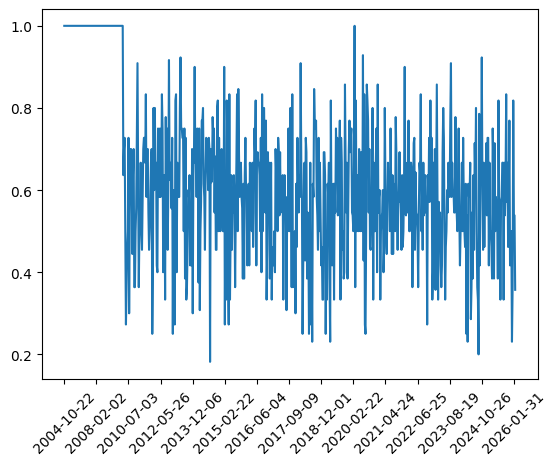

In [4]:
prop = df_model.groupby('date')['winner'].mean()
plt.plot(prop.index, prop.values)
ticks = np.arange(0, len(prop), 50)
ax = plt.gca()
ax.set_xticks(ticks)
plt.xticks(rotation=45) 
plt.show()

In [5]:
def plot_feature_distributions(df_model, feats, n_cols=5):

    n_feats = len(df_model[feats].columns)
    n_rows = math.ceil(n_feats / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()  # make indexing easy

    for i, feat in enumerate(feats):
        sns.histplot(df_model[feat], kde=True, ax=axes[i])
        axes[i].set_title(feat)

    # remove unused subplots (if any)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

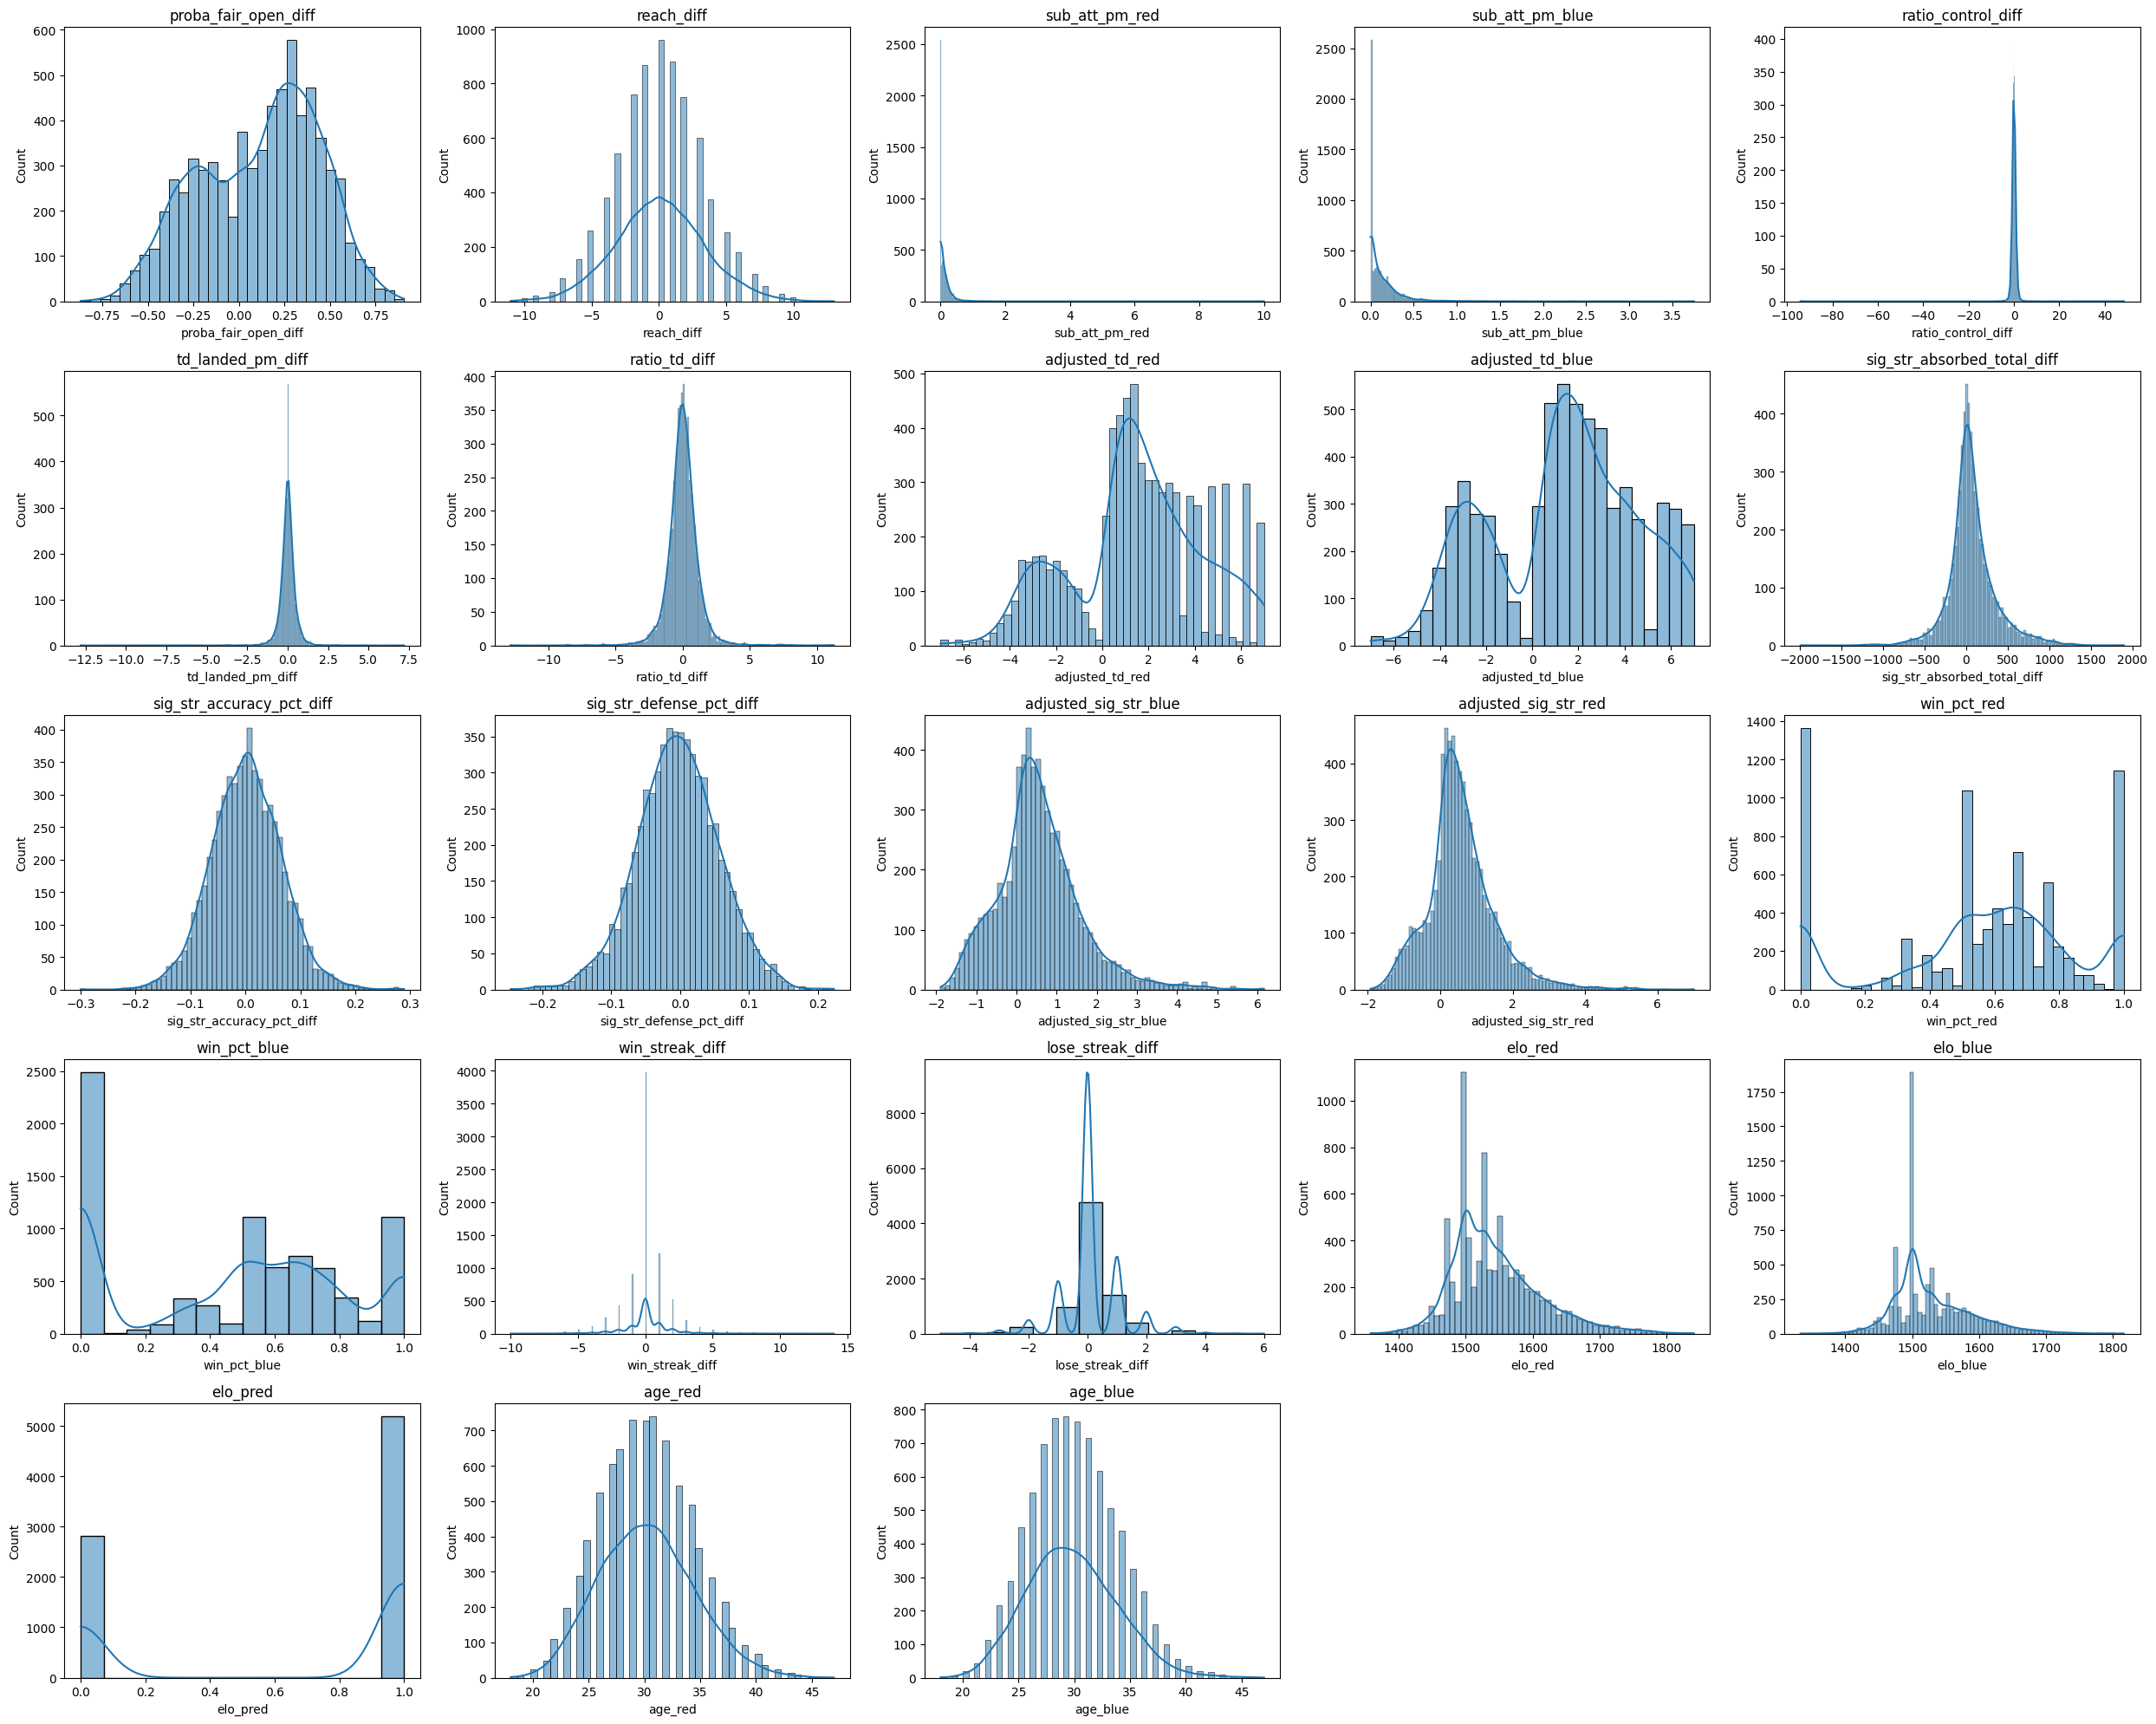

In [8]:
selected_feats_new = [
                  'proba_fair_open_diff', 'reach_diff', 
                  
                  'sub_att_pm_red', 'sub_att_pm_blue',
                  'ratio_control_diff',

                  'td_landed_pm_diff',  
                  'ratio_td_diff', 
                  'adjusted_td_red', 'adjusted_td_blue',

                  'sig_str_absorbed_total_diff', 
                  'sig_str_accuracy_pct_diff',
                  'sig_str_defense_pct_diff',
                  'adjusted_sig_str_blue', 'adjusted_sig_str_red', 
                  
                  'win_pct_red', 'win_pct_blue',
                  'win_streak_diff', 'lose_streak_diff',
                  'elo_red', 'elo_blue', 'elo_pred', 'age_red', 'age_blue',
                  ]

plot_feature_distributions(df_model, selected_feats_new)

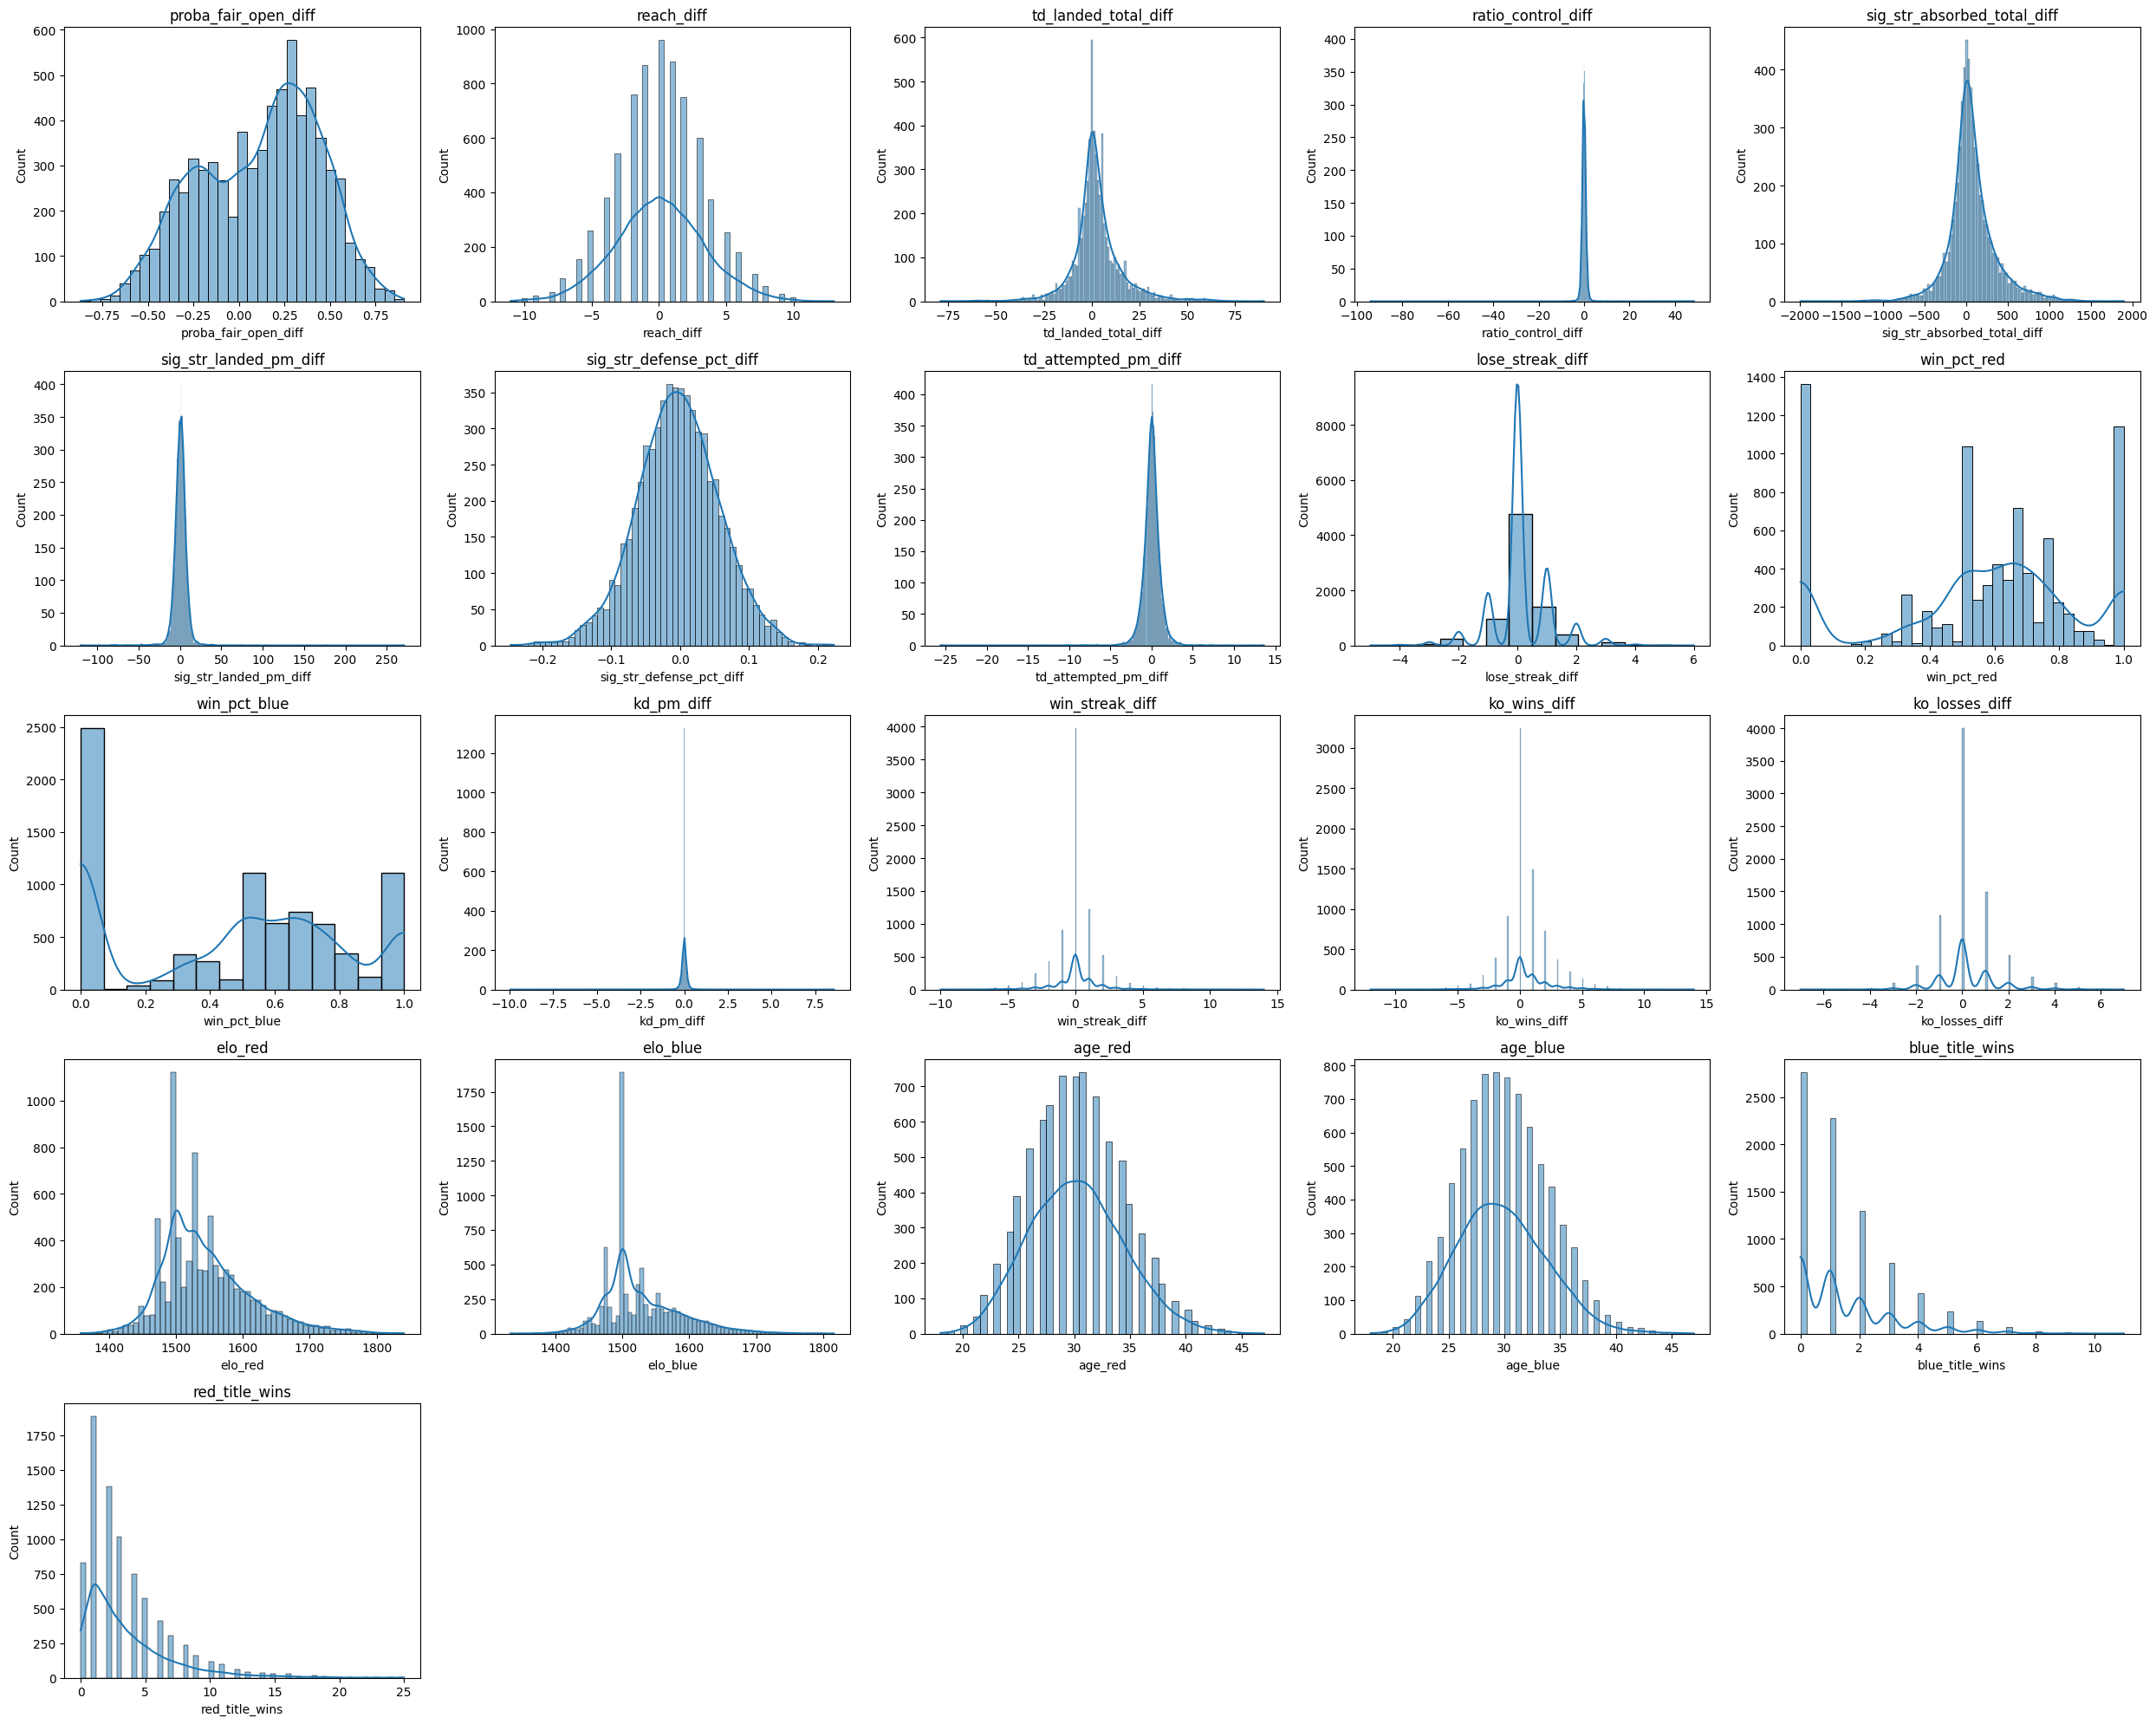

In [37]:
plot_feature_distributions(df_model, selected_feats)

In [33]:
non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'proba_fair_close1_red','proba_fair_close1_blue','proba_fair_close2_red','proba_fair_close2_blue',
    'performance_bonus_winner', 'fight_otn_bonus', 'close1_blue','close1_red', 'close2_blue', 'close2_red'
] 


selected_feats = [
                  'proba_fair_open_diff', 'reach_diff', 
                  'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_defense_pct_diff', 'td_attempted_pm_diff',
                  'lose_streak_diff', 'win_pct_red', 'win_pct_blue', 'kd_pm_diff', 'win_streak_diff', 'ko_wins_diff', 'ko_losses_diff', 
                  'elo_red', 'elo_blue', 'age_red', 'age_blue',
                  'blue_title_wins', 'red_title_wins'
                  ]

outlier_dict = {'td_landed_total_diff':[-50,50], 'ratio_control_diff':[-10,10],'sig_str_absorbed_total_diff':[-1000,1100], 
                'sig_str_landed_pm_diff':[-35,35], 'td_attempted_pm_diff':[-5,5],  'kd_pm_diff':[-.35,.35]
    }

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)
builder.filter_by_year(1990, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(selected_feats, outlier_dict=outlier_dict)


Filtered: kept 7069 rows from year 1990 onward.
PREPARE SHAPE: (5137, 290)
MODEL SHAPE: (4682, 290)
Categorical columns: []
Numerical columns: ['proba_fair_open_diff', 'reach_diff', 'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_defense_pct_diff', 'td_attempted_pm_diff', 'lose_streak_diff', 'win_pct_red', 'win_pct_blue', 'kd_pm_diff', 'win_streak_diff', 'ko_wins_diff', 'ko_losses_diff', 'elo_red', 'elo_blue', 'age_red', 'age_blue', 'blue_title_wins', 'red_title_wins']


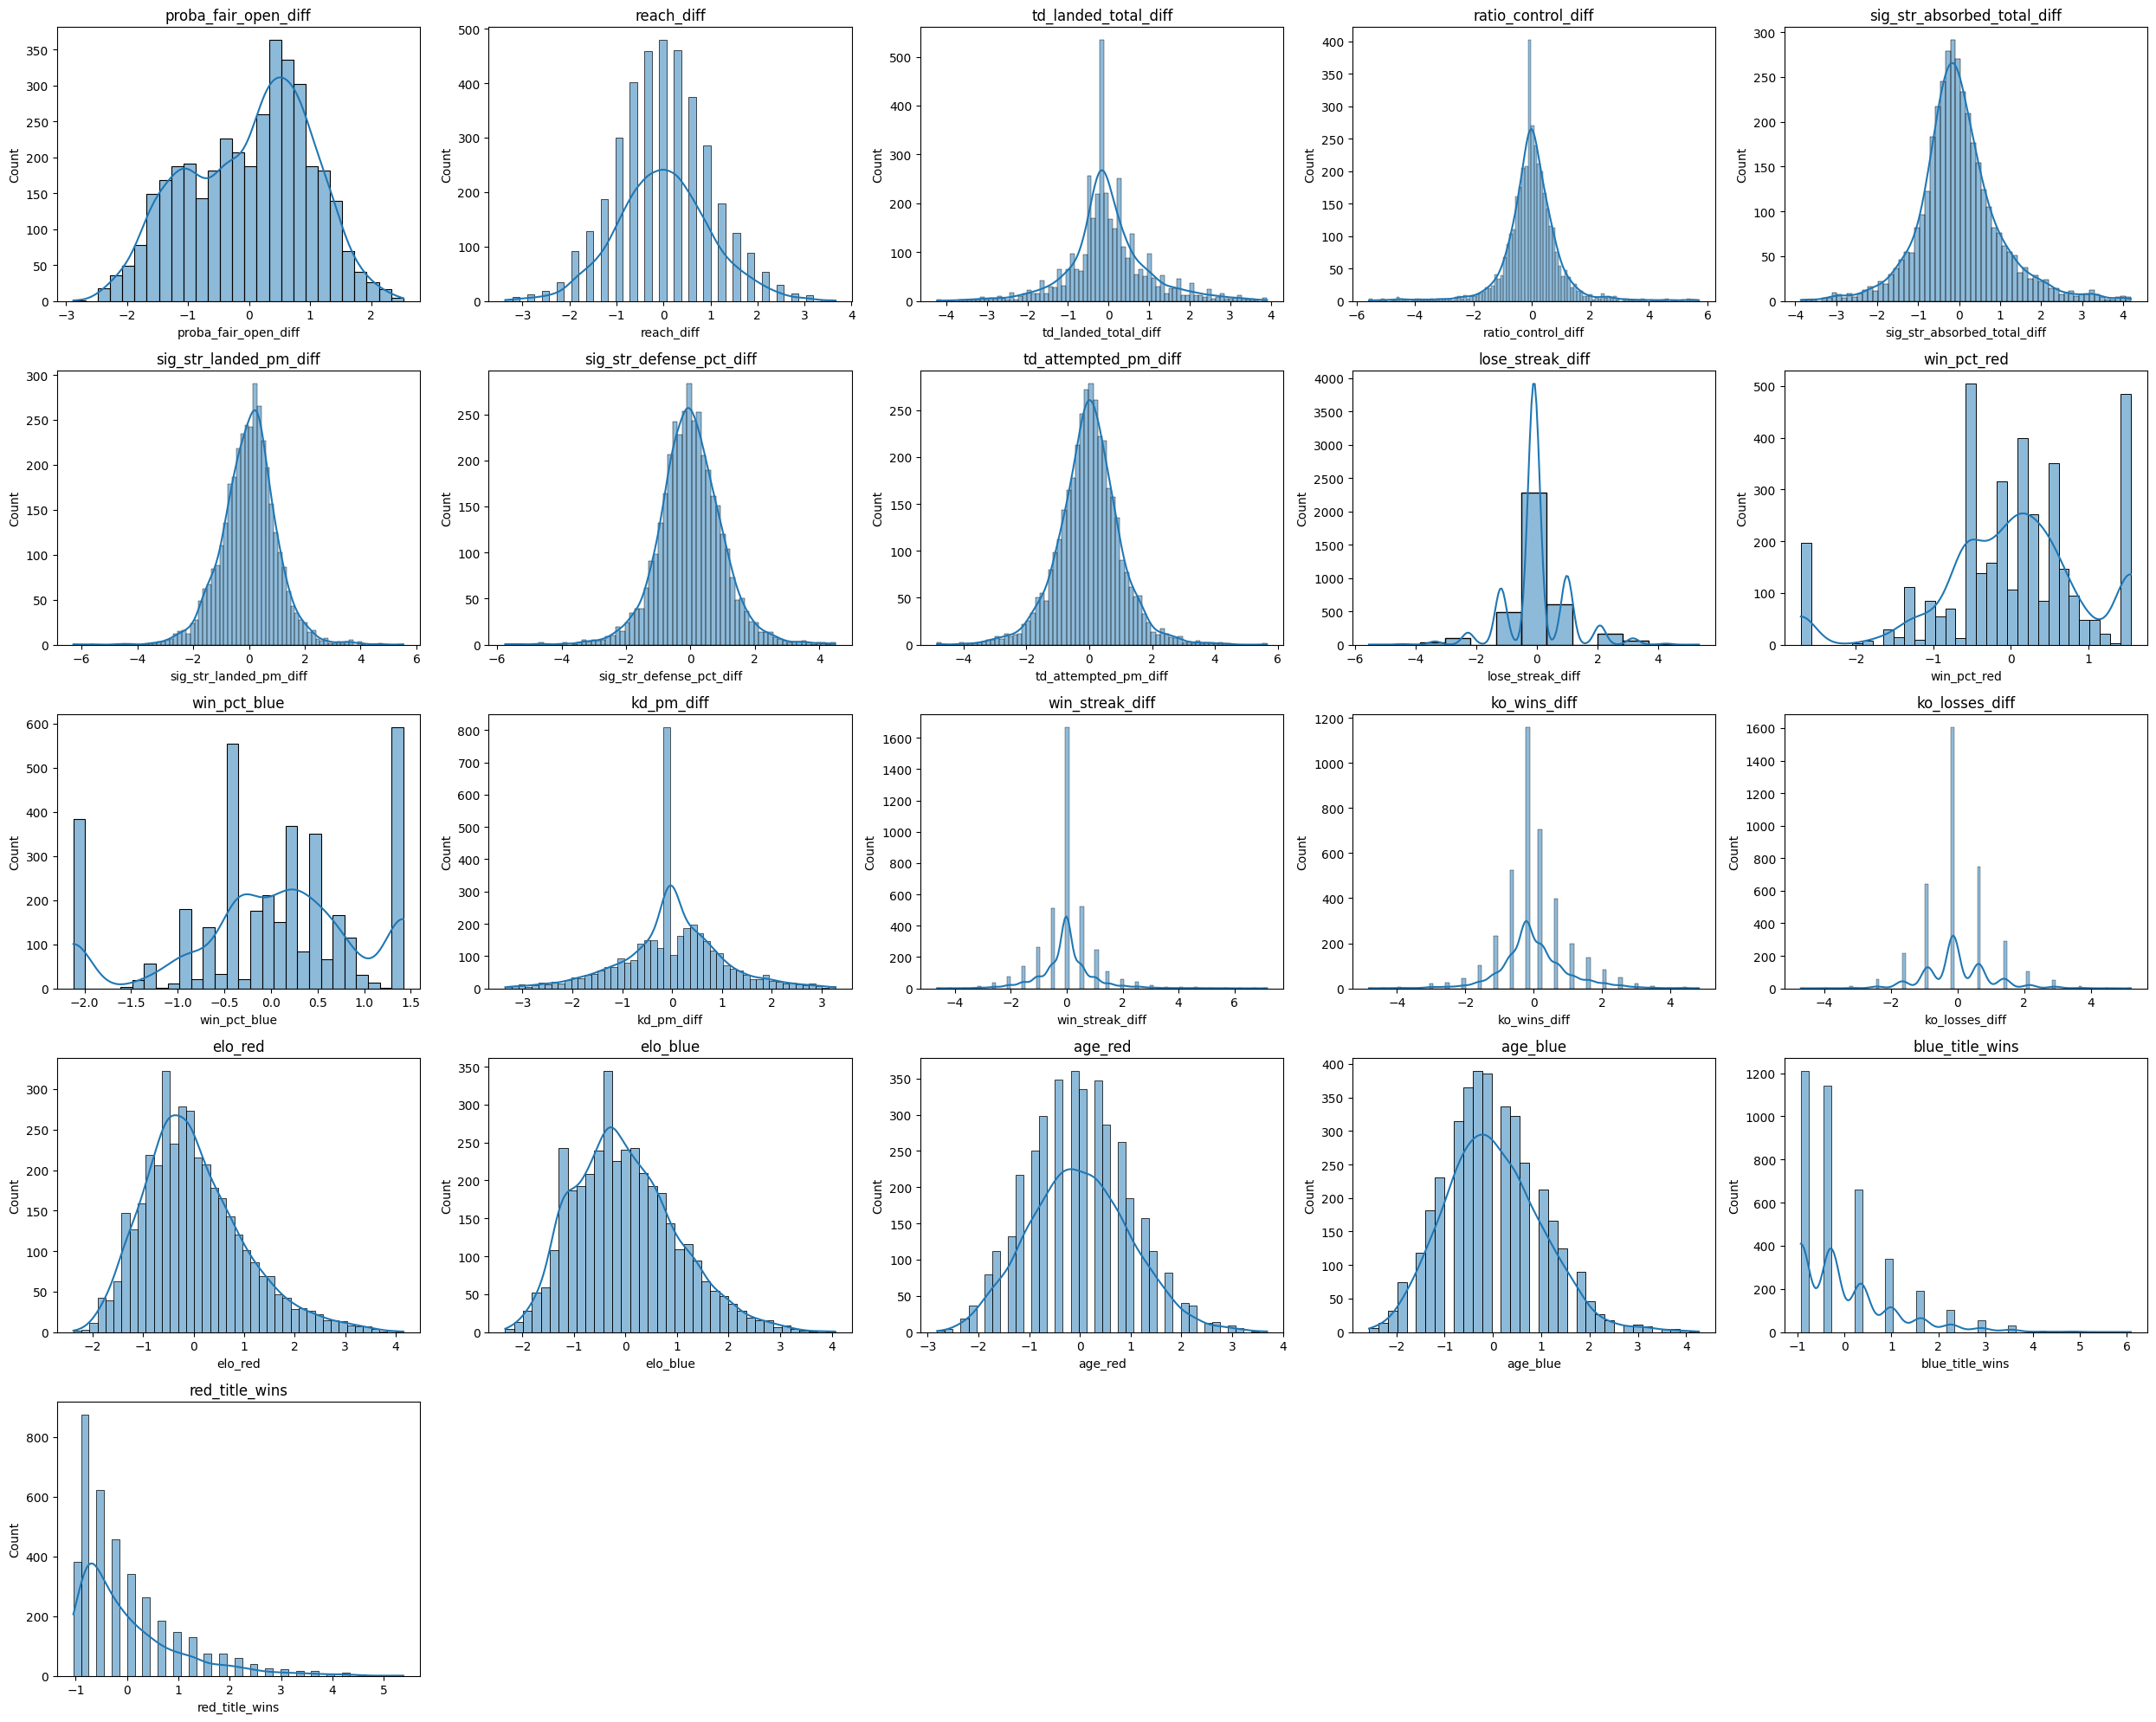

In [ ]:
selected_feats =  ['proba_fair_open_diff', 'reach_diff', 
                  'td_landed_total_diff', 'ratio_control_diff', 'sig_str_absorbed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_defense_pct_diff', 'td_attempted_pm_diff',
                  'lose_streak_diff', 'win_pct_red', 'win_pct_blue', 'kd_pm_diff', 'win_streak_diff', 'ko_wins_diff', 'ko_losses_diff', 
                  'elo_red', 'elo_blue', 'age_red', 'age_blue',
                  'blue_title_wins', 'red_title_wins'
                  ]


plot_feature_distributions(X_train, selected_feats)

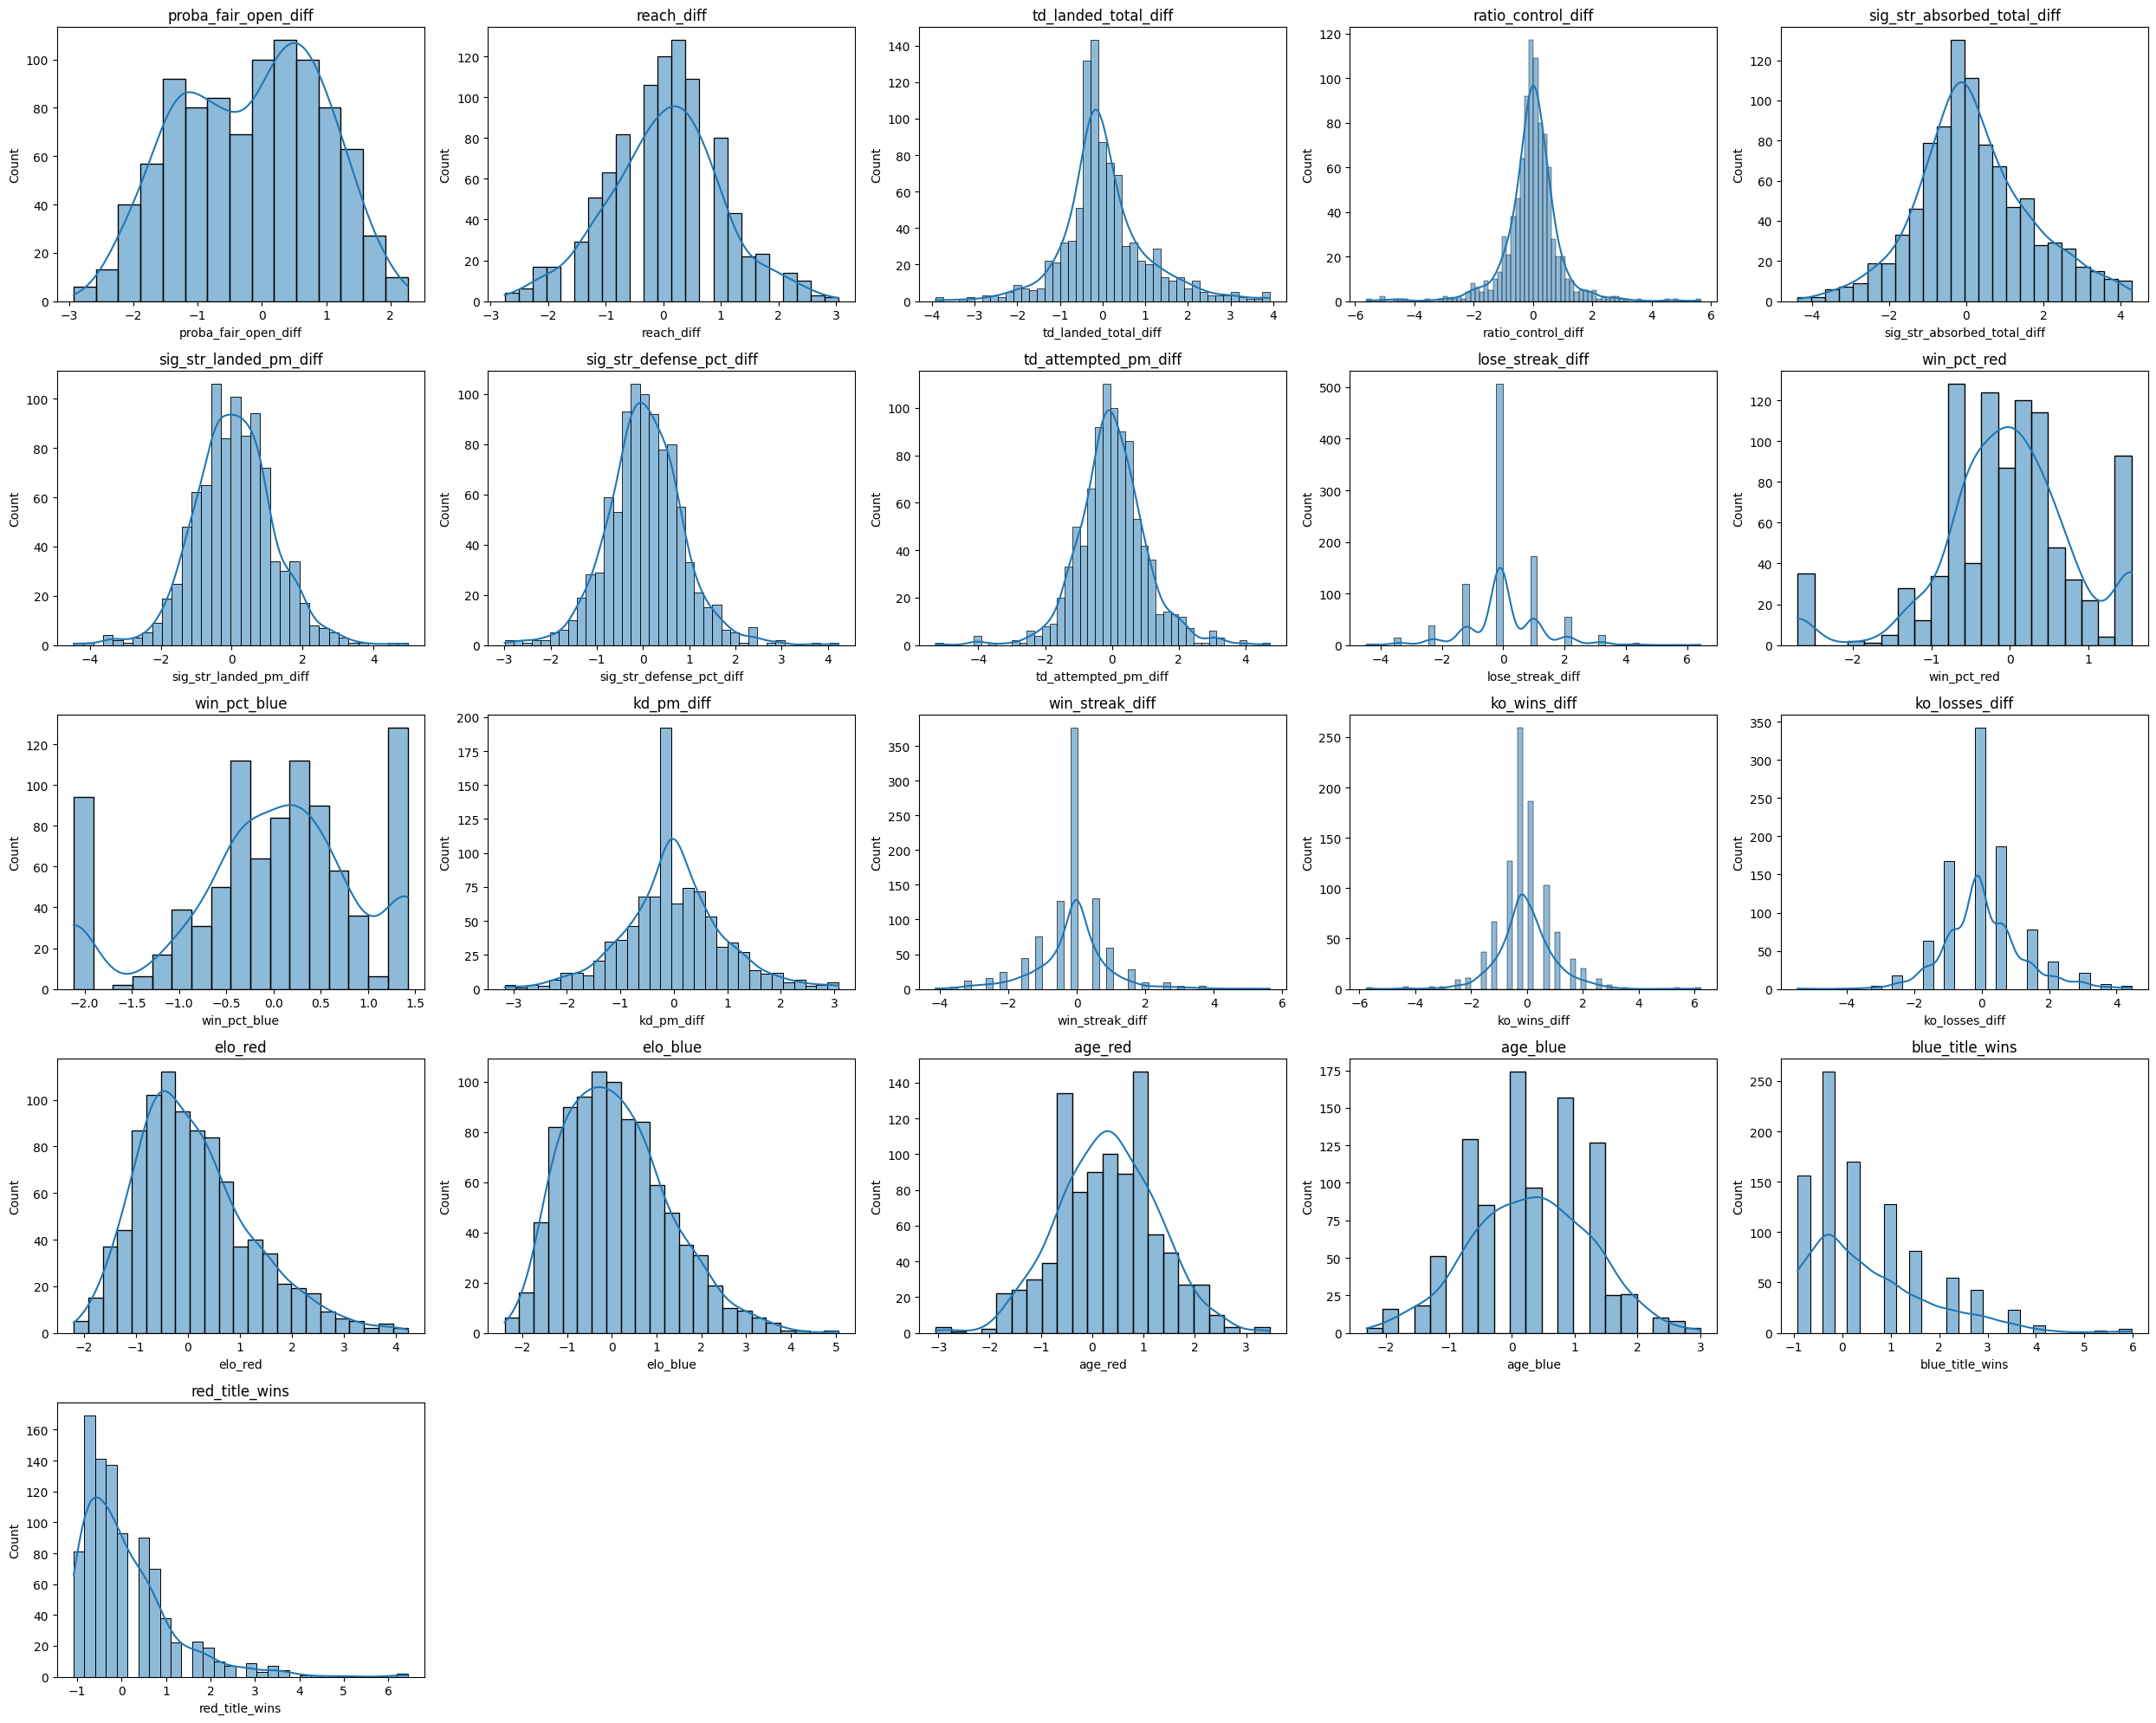

In [29]:
plot_feature_distributions(X_test, selected_feats)

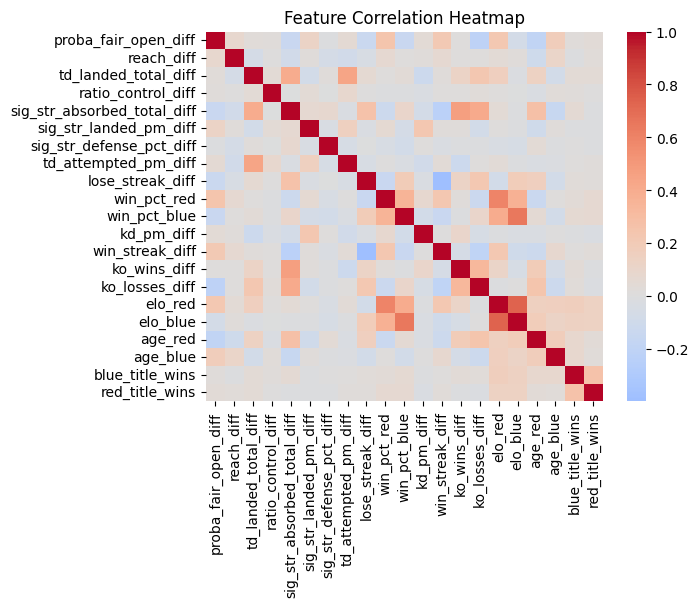

In [53]:
corr = X_train.corr()
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()